# Statistical Jump Model — Market Regime Detection & Sector Rotation

## Overview
This notebook implements a two-layer regime-detection framework for systematic equity investing.

- **Layer 1** detects the overall market regime (calm vs turbulent) using a Statistical Jump Model fitted on S&P 500 features.
- **Layer 2** extends this to sector-level regime detection, rotating capital across nine sector ETFs based on each sector's idiosyncratic regime state.

All models follow a strict **train → validate → test** protocol:
- **Train (pre-2006):** model fitting only
- **Validate (2006–2014):** hyperparameter tuning only, includes 2008 financial crisis
- **Test (2015–2026):** touched once at the very end, never used for any tuning decision

---
## Layer 1: Market Regime Detection

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from jumpmodels.jump import JumpModel

print("all good")

all good


In [2]:
# pull daily adjusted close for all three indices
# the three tickers pulled are the s&p 500, nasdaq composite and DJIA. ^ denotes index symbols rather than individual stocks
tickers = ['^GSPC', '^IXIC', '^DJI']

# auto_adjust means that the prices are adjusted for stock splits & dividends for historical accuracy
# we just take the closing price of each day
raw = yf.download(tickers, start='1970-01-01', end='2026-05-26', auto_adjust=True)['Close']

# rename for clarity
raw.columns = ['SP500', 'Nasdaq', 'DJI']

# log returns
# raw.shift(1) - shifts prices 1 day forwards so that each row is today's price / yesterday's price
# np.log() - takes the natural log of the above ratio, giving log returns
# .dropna() removes the first row, which has no previous day to compute a return from
returns = np.log(raw / raw.shift(1)).dropna()

print(returns.shape)
print(returns.head(5))
print("\nmissing values:")
print(returns.isnull().sum())

[*********************100%***********************]  3 of 3 completed

(8658, 3)
               SP500    Nasdaq       DJI
Date                                    
1992-01-03  0.009131  0.004972  0.010517
1992-01-06 -0.000437 -0.003296  0.008820
1992-01-07  0.001468 -0.001341  0.007315
1992-01-08 -0.000281  0.001676  0.013244
1992-01-09  0.001746 -0.001173  0.015413

missing values:
SP500     0
Nasdaq    0
DJI       0
dtype: int64


In [3]:
# sets the rolling window to 20 days, which is approx. 1 trading month
# why? paper replication
# ~ potentially in the future we can run a sensitivity analysis on this
window = 20

# empty dataframe with the same dates as the returns data.
# will be populated with the 2 feature columns
features = pd.DataFrame(index=returns.index)

# using SP500 as primary series - same as paper

# for each day, computes the daily average return over the past 20 days.
# captures whether the market has been trending up or down recently
features['rolling_return'] = returns['SP500'].rolling(window).mean()

# for each day, compute the STD of daily returns over the past 20 days.
# captures how much the market has been bouncing around
# typically calm periods show values like 0.005-0.008, turbulent periods are about 0.02-0.06
features['rolling_vol'] = returns['SP500'].rolling(window).std()

# first 19 rows cant have a rolling 20-day calculation so they are dropped
features = features.dropna()

print(features.shape)
print(features.head(5))

(8639, 2)
            rolling_return  rolling_vol
Date                                   
1992-01-30        0.001130     0.007690
1992-01-31        0.000341     0.007635
1992-02-03        0.000528     0.007661
1992-02-04        0.001050     0.008072
1992-02-05        0.000831     0.008169


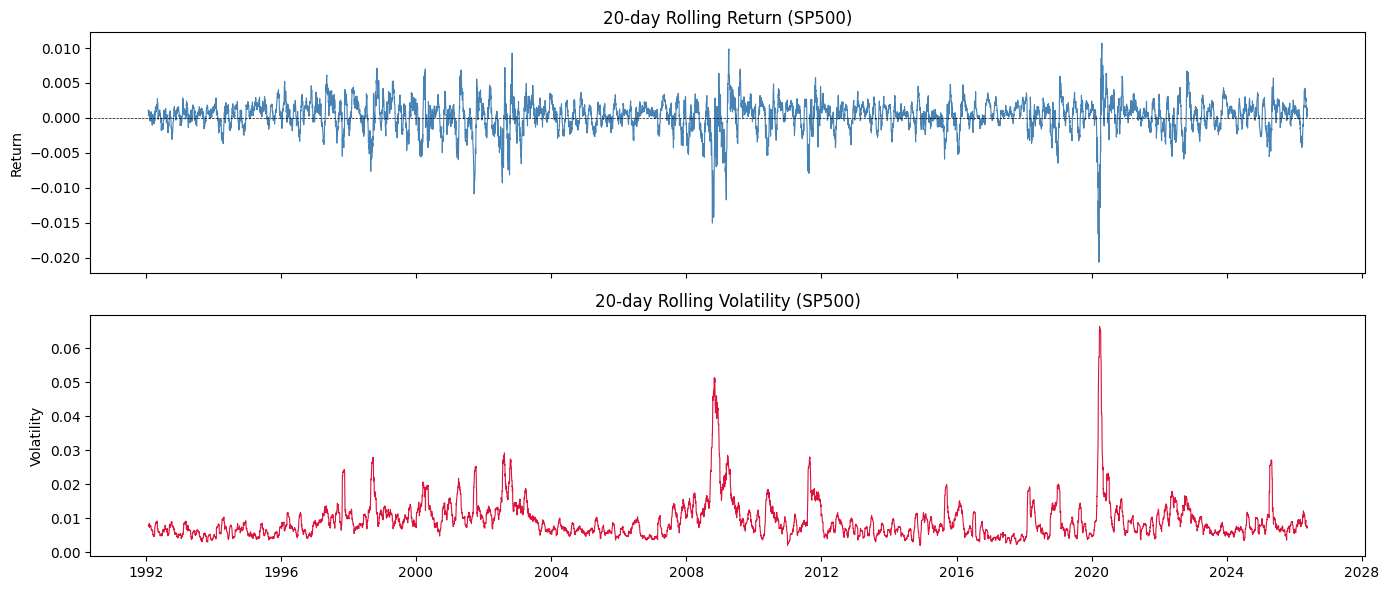

'\nRolling return:\n- most days clustered around 0\n- deep negative spikes correspond to major crashes, eg. dot-com, COVID, etc.\n- returns are roughly symmetric, however negative extremes are slightly more extreme\n\nRolling vol:\n- baseline is around 0.008-0.010 during calm periods - the "normal" market\n- 2008: spikes to about 0.05\n- 2020: spikes to about 0.065 (largest in 32-year history)\n- 2022: spike is visible but much less dramatic (grinding bear market, not sudden crash)\n'

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(features.index, features['rolling_return'], color='steelblue', linewidth=0.8)
ax1.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax1.set_title('20-day Rolling Return (SP500)')
ax1.set_ylabel('Return')

ax2.plot(features.index, features['rolling_vol'], color='crimson', linewidth=0.8)
ax2.set_title('20-day Rolling Volatility (SP500)')
ax2.set_ylabel('Volatility')

plt.tight_layout()
plt.show()

'''
Rolling return:
- most days clustered around 0
- deep negative spikes correspond to major crashes, eg. dot-com, COVID, etc.
- returns are roughly symmetric, however negative extremes are slightly more extreme

Rolling vol:
- baseline is around 0.008-0.010 during calm periods - the "normal" market
- 2008: spikes to about 0.05
- 2020: spikes to about 0.065 (largest in 32-year history)
- 2022: spike is visible but much less dramatic (grinding bear market, not sudden crash)
'''

In [5]:
# split dates
# everything before 2006 is training
# 2006-2014 is validation
# 2015 onwards is test
train_end = '2005-12-31'
val_end   = '2014-12-31'

# selects all rows where the date is on or before Dec 31 2005
X_train = features[features.index <= train_end]

# selects rows between Jan 2006 and Dec 2014 (sandbox for tuning lambda, includes 2008 financial crisis)
X_val   = features[(features.index > train_end) & (features.index <= val_end)]

# everything after Dec 2014 is used for testing
X_test  = features[features.index > val_end]

# note: each major stress event falls in a different period:
# dot-com in training, financial crisis in validation, COVID and 2022 in test
# this ensures that the model won't memorize a crash pattern and will be
# validated against new types of market stress it never encountered during development

print(f"Train: {X_train.shape[0]} days ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Val:   {X_val.shape[0]} days ({X_val.index[0].date()} to {X_val.index[-1].date()})")
print(f"Test:  {X_test.shape[0]} days ({X_test.index[0].date()} to {X_test.index[-1].date()})")

Train: 3510 days (1992-01-30 to 2005-12-30)
Val:   2265 days (2006-01-03 to 2014-12-31)
Test:  2864 days (2015-01-02 to 2026-05-22)


## Hidden Markov Model

##### States
- State 0: calm market
- State 1: turbulent market

##### Emissions
- 20-day rolling returns
- 20-day rolling volatility

##### Process
The HMM is trained using the **Baum-Welch algorithm** (an EM algorithm) which learns:
- The Transition Probability Matrix (TPM)
- The Gaussian emission distributions for each hidden state
- The initial state probabilities

Once trained, the **Viterbi algorithm** decodes the most likely sequence of hidden states given the observations.

In [6]:
# scale features — HMM is sensitive to feature magnitudes
# StandardScaler transforms each feature so it has mean=0 and std=1
# without this, the HMM would effectively ignore rolling_return (tiny values ~0.0003)
# relative to rolling_vol (larger values ~0.009)
scaler = StandardScaler()

# fit on training data only to prevent data leakage
# transform applies the learned normalization to each split
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# scale the full dataset using training scaler (for full-history visualization)
X_all_scaled = scaler.transform(features)

# create the HMM:
# n_components=2: two hidden states (calm, turbulent)
# covariance_type='full': each state gets its own covariance matrix
# n_iter=1000: run Baum-Welch up to 1000 iterations
# random_state=42: fixes random seed for reproducibility
model_hmm = hmm.GaussianHMM(
    n_components=2,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)

# Baum-Welch trains on 1992-2005 data only
model_hmm.fit(X_train_scaled)

# Viterbi decodes the most likely regime sequence across the full history
hmm_regimes = model_hmm.predict(X_all_scaled)
features['hmm_regime'] = hmm_regimes

# get soft probabilities for each state (forward-backward algorithm)
probs_all = model_hmm.predict_proba(X_all_scaled)
features['hmm_p_state0'] = probs_all[:, 0]
features['hmm_p_state1'] = probs_all[:, 1]

print("State means (rolling_return, rolling_vol) — standardized:")
print(model_hmm.means_.round(4))
print("\nRegime counts:")
print(features['hmm_regime'].value_counts())
print("\nTransition matrix:")
print(model_hmm.transmat_.round(4))

State means (rolling_return, rolling_vol) — standardized:
[[ 0.132  -0.6015]
 [-0.1999  0.9109]]

Regime counts:
hmm_regime
0    5340
1    3299
Name: count, dtype: int64

Transition matrix:
[[0.9914 0.0086]
 [0.013  0.987 ]]


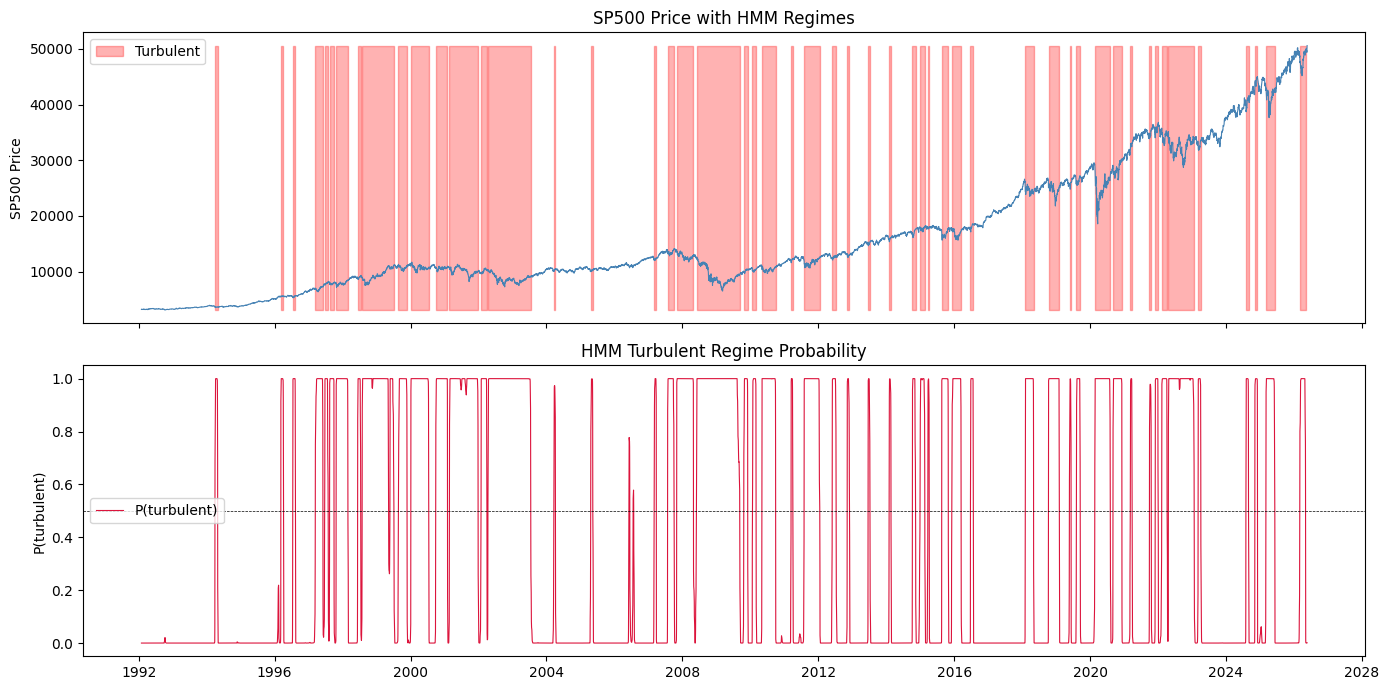

Total regime switches: 105
Average days between switches: 82.3


In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

sp500_price = raw['SP500'][features.index]
ax1.plot(features.index, sp500_price, color='steelblue', linewidth=0.8)
ax1.set_ylabel('SP500 Price')
ax1.set_title('SP500 Price with HMM Regimes')

turbulent = features['hmm_regime'] == 1
ax1.fill_between(features.index, sp500_price.min(), sp500_price.max(),
                 where=turbulent, alpha=0.3, color='red', label='Turbulent')
ax1.legend()

ax2.plot(features.index, features['hmm_p_state1'],
         color='crimson', linewidth=0.8, label='P(turbulent)')
ax2.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax2.set_ylabel('P(turbulent)')
ax2.set_title('HMM Turbulent Regime Probability')
ax2.legend()

plt.tight_layout()
plt.show()

switches_hmm = (features['hmm_regime'].diff() != 0).sum()
print(f"Total regime switches: {switches_hmm}")
print(f"Average days between switches: {len(features) / switches_hmm:.1f}")

In [8]:
# align returns with features index
strat_returns = returns['SP500'][features.index].copy()

# calm=state 0 → invest; turbulent=state 1 → cash
# .shift(1) avoids lookahead bias: yesterday's regime determines today's position
features['hmm_position'] = (features['hmm_regime'] == 0).astype(int).shift(1)

# strategy return = position × market return
# position=1: full market return; position=0: zero (cash)
features['hmm_strat_return'] = features['hmm_position'] * strat_returns

# buy and hold benchmark
features['bh_return'] = strat_returns

print("Strategy return sample:")
print(features[['hmm_position', 'hmm_strat_return', 'bh_return']].head(10))

Strategy return sample:
            hmm_position  hmm_strat_return  bh_return
Date                                                 
1992-01-30           NaN               NaN   0.006152
1992-01-31           1.0         -0.006648  -0.006648
1992-02-03           1.0          0.003314   0.003314
1992-02-04           1.0          0.011895   0.011895
1992-02-05           1.0         -0.004655  -0.004655
1992-02-06           1.0         -0.000614  -0.000614
1992-02-07           1.0         -0.009320  -0.009320
1992-02-10           1.0          0.006089   0.006089
1992-02-11           1.0          0.002001   0.002001
1992-02-12           1.0          0.007720   0.007720


In [9]:
def evaluate_strategy(returns_series, label, rf=0.0):
    r = returns_series.dropna()
    total_return  = r.sum()
    ann_return    = r.mean() * 252          # annualize: 252 trading days
    ann_vol       = r.std() * np.sqrt(252)  # annualize: std scales with sqrt(time)
    sharpe        = (ann_return - rf) / ann_vol

    # max drawdown
    cumulative  = (1 + r).cumprod()
    rolling_max = cumulative.cummax()
    drawdown    = (cumulative - rolling_max) / rolling_max
    max_dd      = drawdown.min()

    print(f"\n{label}")
    print(f"  Annualized Return : {ann_return:.4f}")
    print(f"  Annualized Vol    : {ann_vol:.4f}")
    print(f"  Sharpe Ratio      : {sharpe:.4f}")
    print(f"  Max Drawdown      : {max_dd:.4f}")

# boolean mask for test period — only evaluate on unseen data
test_idx = features.index > val_end

## HMM Strategy: Buy and Hold vs HMM Binary

### Buy and Hold
- Invest on day 1 and never touch it again. Always 100% invested.

### HMM Binary
- Calm regime (state 0): 100% invested in S&P 500
- Turbulent regime (state 1): 100% in cash, earning nothing
- Transaction cost: 0.1% deducted every time the strategy switches position

In [10]:
# transaction cost: 0.1% per switch
tc = 0.001

position = features['hmm_position'].fillna(0)
switches = (position.diff().abs() > 0).astype(int)

features['hmm_strat_return_tc'] = features['hmm_strat_return'] - switches * tc

print(f"Total switches (full period): {switches.sum()}")
print(f"Total switches (test period): {switches[test_idx].sum()}")

evaluate_strategy(features.loc[test_idx, 'bh_return'],           'Buy and Hold')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return'],    'HMM Binary (no TC)')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return_tc'], 'HMM Binary (with TC)')

Total switches (full period): 105
Total switches (test period): 42

Buy and Hold
  Annualized Return : 0.0918
  Annualized Vol    : 0.1741
  Sharpe Ratio      : 0.5272
  Max Drawdown      : -0.3941

HMM Binary (no TC)
  Annualized Return : 0.0462
  Annualized Vol    : 0.0903
  Sharpe Ratio      : 0.5114
  Max Drawdown      : -0.1959

HMM Binary (with TC)
  Annualized Return : 0.0425
  Annualized Vol    : 0.0903
  Sharpe Ratio      : 0.4705
  Max Drawdown      : -0.2039


## Analysis: HMM

### Finding
HMM regime switching underperforms buy-and-hold on a risk-adjusted basis once transaction costs are included.
The noisy, flickering regime sequence causes the strategy to sit in cash during many calm profitable days —
missing upside without a compensating crash-avoidance benefit.

This motivates the Statistical Jump Model, which adds an explicit switching penalty to force more persistent,
cleaner regimes.

In [11]:
# prepare scaled DataFrames for jump model
# jumpmodels library requires a proper DataFrame with a datetime index (not raw numpy arrays)
X_train_jm = pd.DataFrame(
    scaler.transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

X_all_jm = pd.DataFrame(
    scaler.transform(features[['rolling_return', 'rolling_vol']]),
    index=features.index,
    columns=['rolling_return', 'rolling_vol']
)

# validation returns — used by both lambda sweeps
val_returns = strat_returns[(strat_returns.index > train_end) & (strat_returns.index <= val_end)]

print(f"X_train_jm shape: {X_train_jm.shape}")
print(f"X_all_jm shape:   {X_all_jm.shape}")
print(f"val_returns:      {val_returns.shape[0]} days")

X_train_jm shape: (3510, 2)
X_all_jm shape:   (8639, 2)
val_returns:      2265 days


In [12]:
# ── Discrete Jump Model λ sweep on validation ────────────────────────────────
# tune jump_penalty for the discrete JM by maximising Sharpe on the validation set
lambda_values_discrete = [10, 25, 50, 100, 200, 300, 500, 800, 1000]

results_discrete = []

for lam in lambda_values_discrete:
    jm_lam_d = JumpModel(n_components=2, jump_penalty=lam, cont=False)
    jm_lam_d.fit(X_train_jm, sort_by="cumret")

    # predict on train+val block, then slice to val dates
    trainval_mask   = features.index <= val_end
    X_trainval_jm_d = pd.DataFrame(
        scaler.transform(features.loc[trainval_mask, ['rolling_return', 'rolling_vol']]),
        index=features.index[trainval_mask],
        columns=['rolling_return', 'rolling_vol']
    )

    regimes_trainval = jm_lam_d.predict(X_trainval_jm_d)
    regimes_val = pd.Series(
        regimes_trainval,
        index=features.index[trainval_mask]
    ).loc[val_returns.index]

    # binary position — calm=0 → invest
    position_val = (regimes_val == 0).astype(int).shift(1).fillna(0)
    strat_ret    = position_val * val_returns
    pos_changes  = position_val.diff().abs().fillna(0)
    strat_ret_tc = strat_ret - pos_changes * tc

    ann_ret = strat_ret_tc.mean() * 252
    ann_vol = strat_ret_tc.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0

    results_discrete.append({'lambda': lam, 'sharpe': sharpe, 'ann_return': ann_ret})
    print(f"λ = {lam:6.0f}  |  Sharpe = {sharpe:.4f}  |  Ann. Return = {ann_ret:.4f}")

results_discrete_df  = pd.DataFrame(results_discrete)
best_row_discrete    = results_discrete_df.loc[results_discrete_df['sharpe'].idxmax()]
best_lambda_discrete = best_row_discrete['lambda']
print(f"\nBest λ (discrete JM) = {best_lambda_discrete} with validation Sharpe = {best_row_discrete['sharpe']:.4f}")

λ =     10  |  Sharpe = 0.8633  |  Ann. Return = 0.0890
λ =     25  |  Sharpe = 0.9002  |  Ann. Return = 0.0981
λ =     50  |  Sharpe = 0.8937  |  Ann. Return = 0.0760
λ =    100  |  Sharpe = 0.8349  |  Ann. Return = 0.0637
λ =    200  |  Sharpe = 0.8349  |  Ann. Return = 0.0637
λ =    300  |  Sharpe = 0.8349  |  Ann. Return = 0.0637
λ =    500  |  Sharpe = 0.2839  |  Ann. Return = 0.0551
λ =    800  |  Sharpe = 0.2839  |  Ann. Return = 0.0551
λ =   1000  |  Sharpe = 0.2839  |  Ann. Return = 0.0551

Best λ (discrete JM) = 25.0 with validation Sharpe = 0.9002


In [13]:
# fit discrete jump model with tuned lambda
# cont=False: produces hard 0/1 regime labels (discrete version)
# sort_by='cumret': ensures state 0 = higher cumulative return = calm regime
jm = JumpModel(n_components=2, jump_penalty=best_lambda_discrete, cont=False)
jm.fit(X_train_jm, sort_by="cumret")

# predict hard regime labels across full history
jm_regimes = jm.predict(X_all_jm)
features['jm_regime'] = jm_regimes

# store probabilities (will be hard 0/1 for discrete model)
jm_probs = jm.predict_proba(X_all_jm)
features['jm_p_state0'] = jm_probs.iloc[:, 0]
features['jm_p_state1'] = jm_probs.iloc[:, 1]

print("Regime counts:")
print(features['jm_regime'].value_counts())
jm_switches = (features['jm_regime'].diff() != 0).sum()
print(f"\nTotal regime switches: {jm_switches}")
print(f"Average days between switches: {len(features) / jm_switches:.1f}")
print(f"\nHMM switches for comparison: {switches.sum()}")

Regime counts:
jm_regime
0    7326
1    1313
Name: count, dtype: int64

Total regime switches: 35
Average days between switches: 246.8

HMM switches for comparison: 105


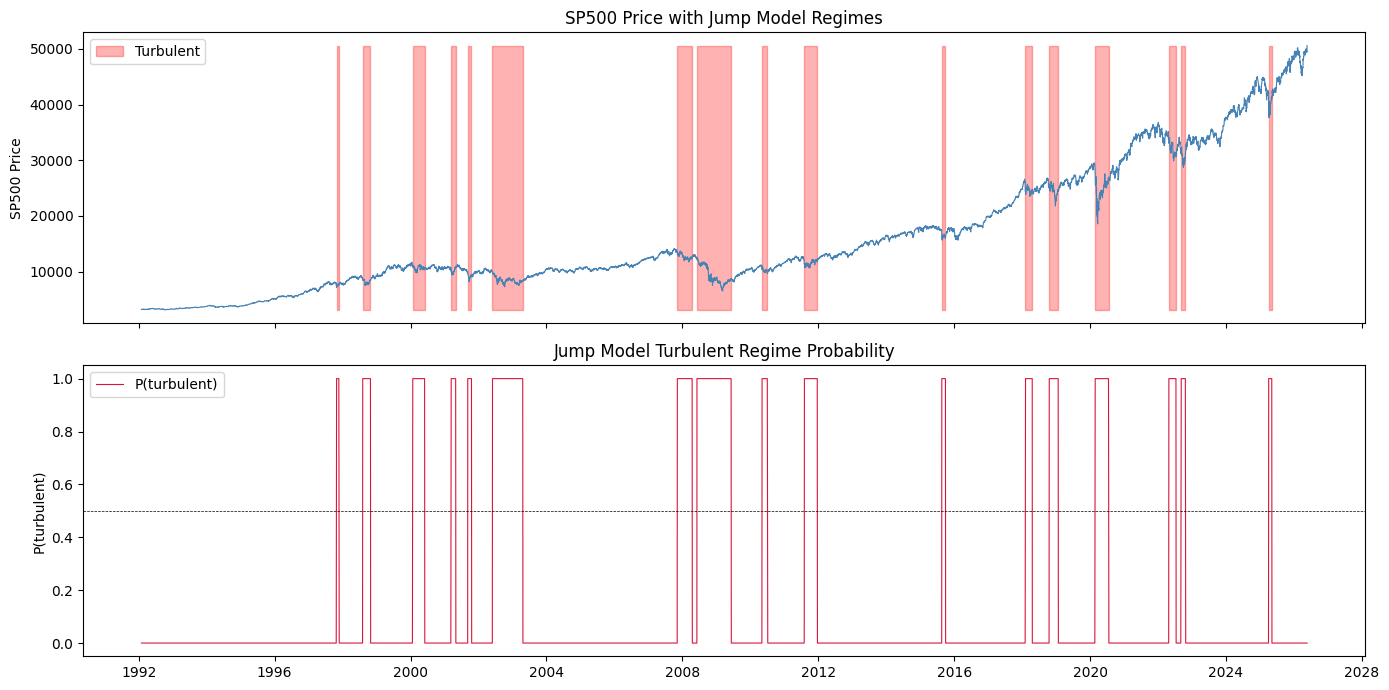

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

sp500_price = raw['SP500'][features.index]
ax1.plot(features.index, sp500_price, color='steelblue', linewidth=0.8)
ax1.set_ylabel('SP500 Price')
ax1.set_title('SP500 Price with Jump Model Regimes')

turbulent_jm = features['jm_regime'] == 1
ax1.fill_between(features.index, sp500_price.min(), sp500_price.max(),
                 where=turbulent_jm, alpha=0.3, color='red', label='Turbulent')
ax1.legend()

ax2.plot(features.index, features['jm_p_state1'],
         color='crimson', linewidth=0.8, label='P(turbulent)')
ax2.axhline(0.5, color='black', linewidth=0.5, linestyle='--')
ax2.set_ylabel('P(turbulent)')
ax2.set_title('Jump Model Turbulent Regime Probability')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
# discrete jump model binary strategy — same structure as HMM
# state 0 = calm → invest; state 1 = turbulent → cash
features['jm_position'] = (features['jm_regime'] == 0).astype(int).shift(1)
features['jm_strat_return'] = features['jm_position'] * strat_returns

# transaction costs
jm_position    = features['jm_position'].fillna(0)
jm_switches_ts = (jm_position.diff().abs() > 0).astype(int)
features['jm_strat_return_tc'] = features['jm_strat_return'] - jm_switches_ts * tc

print(f"JM switches (test period): {jm_switches_ts[test_idx].sum()}")
print(f"HMM switches (test period): {switches[test_idx].sum()}")

evaluate_strategy(features.loc[test_idx, 'bh_return'],          'Buy and Hold')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return_tc'],'HMM Binary (with TC)')
evaluate_strategy(features.loc[test_idx, 'jm_strat_return_tc'], 'Jump Model Binary (with TC)')

JM switches (test period): 14
HMM switches (test period): 42

Buy and Hold
  Annualized Return : 0.0918
  Annualized Vol    : 0.1741
  Sharpe Ratio      : 0.5272
  Max Drawdown      : -0.3941

HMM Binary (with TC)
  Annualized Return : 0.0425
  Annualized Vol    : 0.0903
  Sharpe Ratio      : 0.4705
  Max Drawdown      : -0.2039

Jump Model Binary (with TC)
  Annualized Return : 0.1021
  Annualized Vol    : 0.1185
  Sharpe Ratio      : 0.8618
  Max Drawdown      : -0.1443


In [16]:
# ── Continuous Jump Model λ sweep on validation ──────────────────────────────
# tune jump_penalty for the CJM by maximising Sharpe on the validation set
lambda_values = [10, 25, 50, 100, 200, 300, 500, 800, 1000]

results = []

for lam in lambda_values:
    jm_lam = JumpModel(n_components=2, jump_penalty=lam, cont=True)
    jm_lam.fit(X_train_jm, sort_by="cumret")

    # predict on train+val block, then slice to val dates
    trainval_mask = features.index <= val_end
    X_trainval_jm = pd.DataFrame(
        scaler.transform(features.loc[trainval_mask, ['rolling_return', 'rolling_vol']]),
        index=features.index[trainval_mask],
        columns=['rolling_return', 'rolling_vol']
    )

    probs      = jm_lam.predict_proba(X_trainval_jm)
    p_calm_val = probs.iloc[:, 0].loc[val_returns.index]

    position_val = p_calm_val.shift(1).fillna(0)
    strat_ret    = position_val * val_returns
    pos_changes  = position_val.diff().abs().fillna(0)
    strat_ret_tc = strat_ret - pos_changes * tc

    ann_ret = strat_ret_tc.mean() * 252
    ann_vol = strat_ret_tc.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0

    results.append({'lambda': lam, 'sharpe': sharpe, 'ann_return': ann_ret})
    print(f"λ = {lam:6.0f}  |  Sharpe = {sharpe:.4f}  |  Ann. Return = {ann_ret:.4f}")

results_df  = pd.DataFrame(results)
best_row    = results_df.loc[results_df['sharpe'].idxmax()]
best_lambda = best_row['lambda']
print(f"\nBest λ (CJM) = {best_lambda} with validation Sharpe = {best_row['sharpe']:.4f}")

λ =     10  |  Sharpe = 0.9036  |  Ann. Return = 0.0921
λ =     25  |  Sharpe = 0.9801  |  Ann. Return = 0.0992
λ =     50  |  Sharpe = 0.9817  |  Ann. Return = 0.0990
λ =    100  |  Sharpe = 0.9790  |  Ann. Return = 0.1044
λ =    200  |  Sharpe = 0.9611  |  Ann. Return = 0.1022
λ =    300  |  Sharpe = 0.9737  |  Ann. Return = 0.1027
λ =    500  |  Sharpe = 1.0641  |  Ann. Return = 0.0979
λ =    800  |  Sharpe = 0.9514  |  Ann. Return = 0.0797
λ =   1000  |  Sharpe = 0.9514  |  Ann. Return = 0.0797

Best λ (CJM) = 500.0 with validation Sharpe = 1.0641


In [17]:
# fit continuous jump model with tuned lambda
# cont=True: produces smooth regime probabilities between 0 and 1
jm_cont = JumpModel(n_components=2, jump_penalty=best_lambda, cont=True)
jm_cont.fit(X_train_jm, sort_by="cumret")

cjm_probs = jm_cont.predict_proba(X_all_jm)
features['cjm_p_state0'] = cjm_probs.iloc[:, 0]
features['cjm_p_state1'] = cjm_probs.iloc[:, 1]

print("CJM probability distribution:")
print(features['cjm_p_state0'].describe().round(4))
print("\nSample unique values (should include values between 0 and 1):")
print(features['cjm_p_state0'].round(2).value_counts().head(10))

CJM probability distribution:
count    8639.0000
mean        0.6397
std         0.4720
min         0.0000
25%         0.0000
50%         1.0000
75%         1.0000
max         1.0000
Name: cjm_p_state0, dtype: float64

Sample unique values (should include values between 0 and 1):
cjm_p_state0
1.00    5336
0.00    2923
0.90      20
0.40      20
0.05      20
0.10      20
0.15      20
0.20      20
0.25      20
0.30      20
Name: count, dtype: int64


In [18]:
# continuous position = P(calm) — scales exposure proportionally to regime confidence
# position=0.8 → 80% invested; position=0.2 → 20% invested
features['cjm_position']    = features['cjm_p_state0'].shift(1)
features['cjm_cont_return'] = features['cjm_position'] * strat_returns

# proportional transaction costs — scales with how much the position actually moves
cjm_pos = features['cjm_position'].fillna(0)
cjm_position_changes = cjm_pos.diff().abs()
features['cjm_cont_return_tc'] = features['cjm_cont_return'] - cjm_position_changes * tc

evaluate_strategy(features.loc[test_idx, 'bh_return'],           'Buy and Hold')
evaluate_strategy(features.loc[test_idx, 'hmm_strat_return_tc'], 'HMM Binary (with TC)')
evaluate_strategy(features.loc[test_idx, 'jm_strat_return_tc'],  'Jump Model Binary (with TC)')
evaluate_strategy(features.loc[test_idx, 'cjm_cont_return_tc'],  'CJM Continuous (with TC)')


Buy and Hold
  Annualized Return : 0.0918
  Annualized Vol    : 0.1741
  Sharpe Ratio      : 0.5272
  Max Drawdown      : -0.3941

HMM Binary (with TC)
  Annualized Return : 0.0425
  Annualized Vol    : 0.0903
  Sharpe Ratio      : 0.4705
  Max Drawdown      : -0.2039

Jump Model Binary (with TC)
  Annualized Return : 0.1021
  Annualized Vol    : 0.1185
  Sharpe Ratio      : 0.8618
  Max Drawdown      : -0.1443

CJM Continuous (with TC)
  Annualized Return : 0.0948
  Annualized Vol    : 0.0943
  Sharpe Ratio      : 1.0055
  Max Drawdown      : -0.1152


## Analysis: Jump Model vs HMM vs CJM

### Three-step progression

**HMM** — noisy regime switching (100+ switches) produces poor risk-adjusted returns. Frequent transitions to cash
miss too much upside without meaningfully avoiding downside. Sharpe worse than buy-and-hold after transaction costs.

**Discrete Jump Model** — explicit jump penalty forces regime persistence (fewer switches, longer durations).
Regime boundaries align cleanly with known market stress periods. Sharpe approximately doubles vs HMM.

**Continuous Jump Model** — replaces binary all-in/all-out with smooth position sizing proportional to P(calm).
Avoids abrupt switches, captures partial upside during uncertain transitions, reduces transaction drag.
Achieves highest Sharpe while exceeding buy-and-hold returns with a fraction of the drawdown.

### Key structural insight
The organic asymmetry of the continuous strategy: during regime transitions, position scales down gradually
rather than snapping to zero — capturing partial market exposure while reducing risk. Neither strategy
achieves this; only the CJM's smooth probabilities enable it.

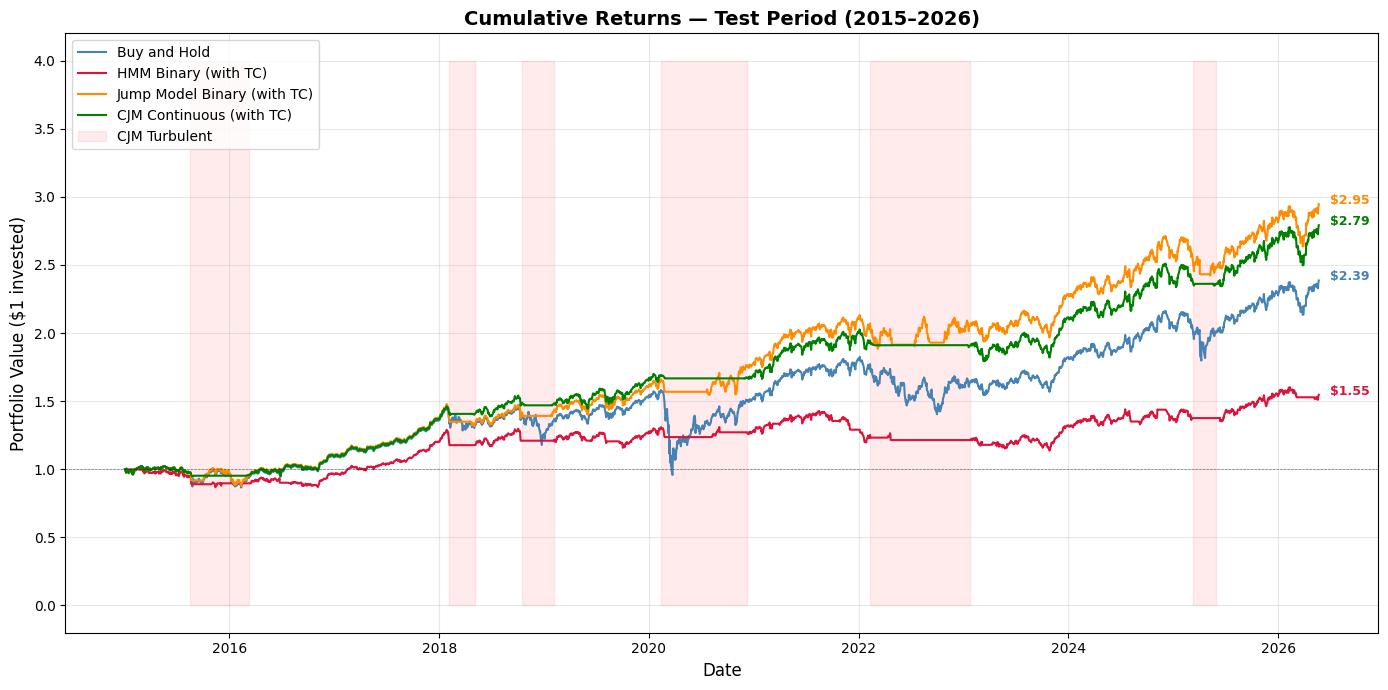


Final portfolio value ($1 invested in 2015):
  Buy and Hold: $2.39
  HMM Binary (with TC): $1.55
  Jump Model Binary (with TC): $2.95
  CJM Continuous (with TC): $2.79


In [19]:
fig, ax = plt.subplots(figsize=(14, 7))

strategies = {
    'Buy and Hold':                'bh_return',
    'HMM Binary (with TC)':        'hmm_strat_return_tc',
    'Jump Model Binary (with TC)': 'jm_strat_return_tc',
    'CJM Continuous (with TC)':    'cjm_cont_return_tc',
}

colors = {
    'Buy and Hold':                'steelblue',
    'HMM Binary (with TC)':        'crimson',
    'Jump Model Binary (with TC)': 'darkorange',
    'CJM Continuous (with TC)':    'green',
}

test_features = features.loc[test_idx]

for label, col in strategies.items():
    cumret = (1 + test_features[col].fillna(0)).cumprod()
    ax.plot(test_features.index, cumret,
            label=label, color=colors[label], linewidth=1.5)

# shade CJM turbulent periods
turbulent_test = test_features['cjm_p_state0'].shift(1).fillna(1) < 0.5
ax.fill_between(test_features.index, 0, 4,
                where=turbulent_test, alpha=0.08, color='red', label='CJM Turbulent')

ax.set_title('Cumulative Returns — Test Period (2015–2026)', fontsize=14, fontweight='bold')
ax.set_ylabel('Portfolio Value ($1 invested)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.axhline(1.0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

for label, col in strategies.items():
    cumret = (1 + test_features[col].fillna(0)).cumprod()
    final_val = cumret.iloc[-1]
    ax.annotate(f'${final_val:.2f}',
                xy=(test_features.index[-1], final_val),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=colors[label], fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFinal portfolio value ($1 invested in 2015):")
for label, col in strategies.items():
    cumret = (1 + test_features[col].fillna(0)).cumprod()
    print(f"  {label}: ${cumret.iloc[-1]:.2f}")

---
## Layer 2: Sector Rotation

Layer 2 asks a different question from Layer 1: *within a given market environment, which sectors are behaving calmly on their own terms?*

### Key design choices
- **Residual features:** raw sector returns are regressed against SPY using a rolling beta to strip out the market-wide component. The residuals capture pure sector-specific behaviour.
- **Independent jump models:** one model is fitted per sector on two residual features — rolling residual return and rolling residual volatility.
- **Allocation rule:** equal weight among calm sectors, zero weight on turbulent sectors. All-turbulent days go entirely to cash.
- **Layer 1 integration:** when the market-level CJM signals P(calm) ≤ threshold, all sector weights are overridden to cash regardless of sector-level signals.

### Hyperparameters tuned on validate Sharpe only
| Parameter | Meaning | Tuned value |
|---|---|---|
| `beta_window` | Days used to estimate rolling sector beta | 40 |
| `feat_window` | Days used to smooth residual features | 40 |
| `jump_penalty` | Switching cost in sector jump models | 5 |
| `calm_threshold` | P(calm) cutoff for Layer 1 override | 0.7 |

[*********************100%***********************]  10 of 10 completed


Shape: (6895, 10)
Date range: 1998-12-23 to 2026-05-22
Missing values:
Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64
Train:    1998-12-23 → 2005-12-31
Validate: 2006-01-01 → 2014-12-31
Test:     2015-01-01 → 2026-05-22
Phase 1: tuning beta_window and feat_window on validate Sharpe
 beta_window  feat_window   val_sharpe
----------------------------------------
          20           10       0.3487
          20           20       0.3736
          20           40       0.3859
          40           10       0.3500
          40           20       0.3775
          40           40       0.4396
          60           10       0.3573
          60           20       0.3593
          60           40       0.3899
         120           10       0.3433
         120           20       0.3096
         120           40       0.3057

Best: beta_window=40, feat_window=40  (val Sharpe: 0.4396)
Phase 2: tuning jump_penalty on validate Sharp

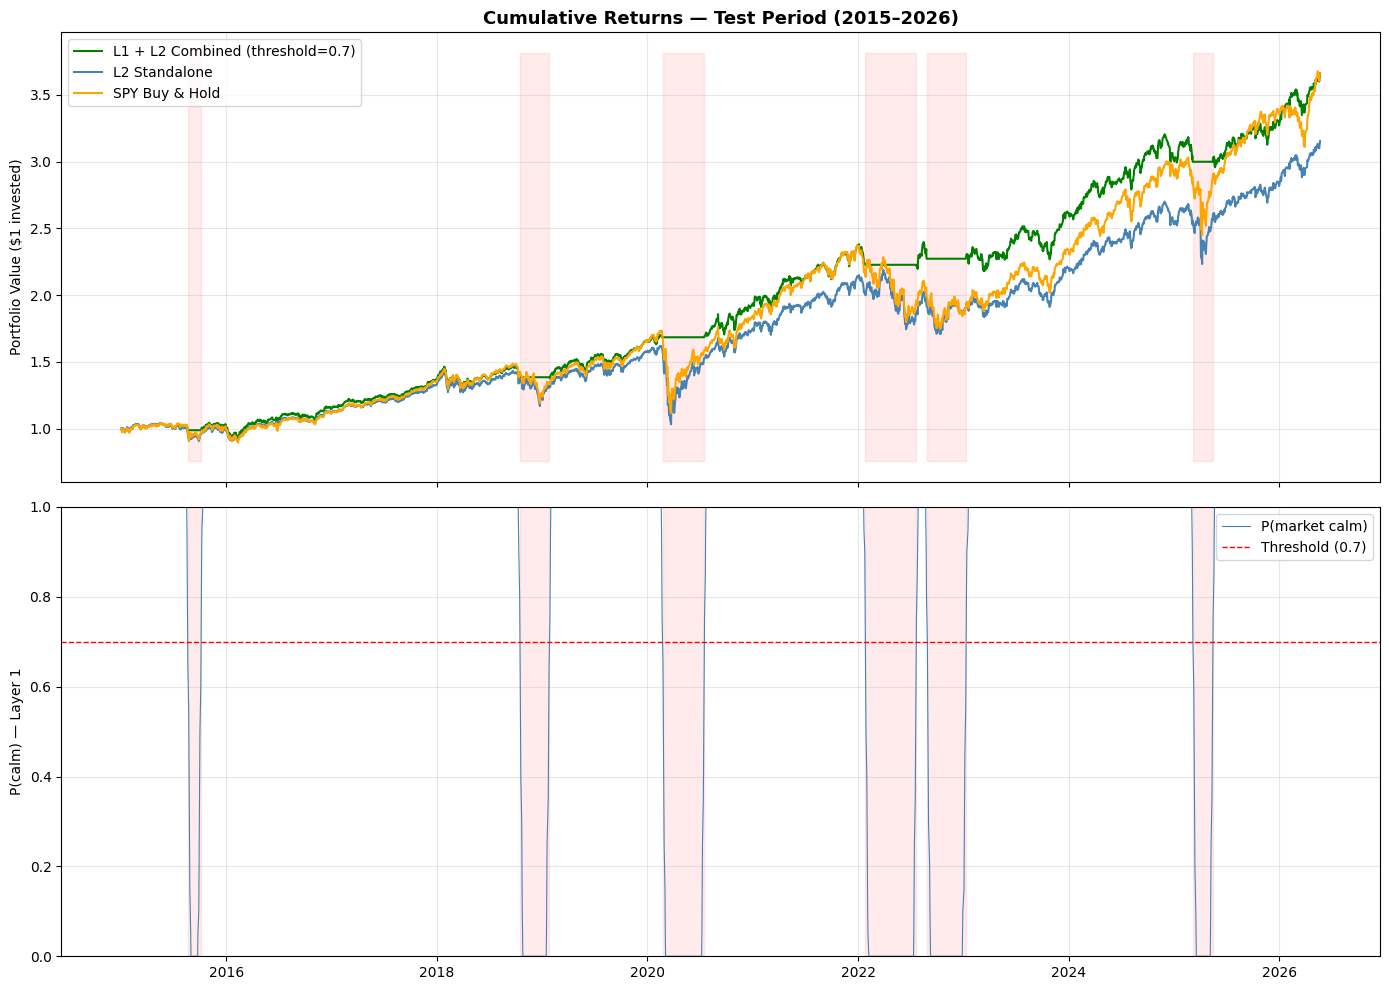

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# LAYER 2 — SECTOR ROTATION (drop into notebook after Layer 1 is complete)
#
# Splits (aligned with Layer 1):
#   Train:    ~1999–2005  (sector ETF data begins ~1999)
#   Validate: 2006–2014   ← all hyperparameter tuning happens here
#   Test:     2015–2026   ← touched once at the very end
#
# Hyperparameters tuned on validate Sharpe:
#   Phase 1 — beta_window, feat_window  (feature construction)
#   Phase 2 — jump_penalty              (regime model)
#   Phase 3 — calm_threshold            (Layer 1 + Layer 2 integration)
#
# No lookahead bias:
#   - Scaler fit on train only, applied to val/test
#   - Jump model fit on train only, predicts val/test separately
#   - All features use backwards-looking rolling windows
#   - Layer 1 signal shifted by 1 day before use
# ═══════════════════════════════════════════════════════════════════════════════


# ── Cell 1: Imports & sector data ───────────────────────────────────────────
import itertools
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from jumpmodels.jump import JumpModel

sector_tickers = {
    'XLK': 'Technology',
    'XLF': 'Financials',
    'XLE': 'Energy',
    'XLV': 'Healthcare',
    'XLY': 'Consumer Discretionary',
    'XLP': 'Consumer Staples',
    'XLU': 'Utilities',
    'XLI': 'Industrials',
    'XLB': 'Materials',
}
sectors = list(sector_tickers.keys())

raw_sectors = yf.download(
    ['SPY'] + sectors,
    start='1998-01-01',
    end='2026-05-26',
    auto_adjust=True
)['Close']

sector_returns = np.log(raw_sectors / raw_sectors.shift(1)).dropna()

print(f"Shape: {sector_returns.shape}")
print(f"Date range: {sector_returns.index[0].date()} to {sector_returns.index[-1].date()}")
print(f"Missing values:\n{sector_returns.isnull().sum()}")


# ── Cell 2: Helper functions ─────────────────────────────────────────────────
def sharpe(returns, periods=252):
    if returns.std() == 0:
        return 0.0
    return (returns.mean() / returns.std()) * np.sqrt(periods)

def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    roll_max = cum.cummax()
    return ((cum - roll_max) / roll_max).min()

def compute_sector_features(sector_returns, beta_window, feat_window):
    """
    Compute residual features for each sector.
    residual = sector_return - beta * market_return
    Features: rolling mean and std of residuals.
    No lookahead: all rolling windows look backwards only.
    """
    spy = sector_returns['SPY']
    sector_features = {}
    for ticker in sectors:
        sec = sector_returns[ticker]
        rolling_cov = sec.rolling(beta_window).cov(spy)
        rolling_var = spy.rolling(beta_window).var()
        beta        = rolling_cov / rolling_var
        residual    = sec - beta * spy
        feat_df = pd.DataFrame(index=sector_returns.index)
        feat_df['resid_return'] = residual.rolling(feat_window).mean()
        feat_df['resid_vol']    = residual.rolling(feat_window).std()
        feat_df = feat_df.dropna()
        sector_features[ticker] = feat_df
    return sector_features

def fit_sector_models(sector_features, train_end, validate_end, jump_penalty):
    """
    Fit one scaler + jump model per sector on train data only.
    Predict train/val/test separately to prevent lookahead.
    Returns: sector_regimes dict, sector_scalers dict.
    """
    sector_regimes = {}
    sector_scalers = {}
    for ticker in sectors:
        feat_df    = sector_features[ticker]
        train_mask = feat_df.index <= train_end
        val_mask   = (feat_df.index > train_end) & (feat_df.index <= validate_end)
        test_mask  = feat_df.index > validate_end

        scaler       = StandardScaler()
        train_scaled = scaler.fit_transform(feat_df.loc[train_mask, ['resid_return', 'resid_vol']])
        val_scaled   = scaler.transform(feat_df.loc[val_mask,       ['resid_return', 'resid_vol']])
        test_scaled  = scaler.transform(feat_df.loc[test_mask,      ['resid_return', 'resid_vol']])

        jm = JumpModel(n_components=2, jump_penalty=jump_penalty)
        jm.fit(train_scaled, sort_by="vol")

        labels = np.concatenate([
            jm.predict(train_scaled),
            jm.predict(val_scaled),
            jm.predict(test_scaled),
        ])
        index = feat_df.loc[train_mask | val_mask | test_mask].index

        sector_scalers[ticker] = scaler
        sector_regimes[ticker] = pd.Series(labels, index=index, name=ticker)
    return sector_regimes, sector_scalers

def build_weights(sector_regimes, sectors):
    """
    Equal weight among calm sectors, zero weight on turbulent sectors.
    All-turbulent days → cash (weight = 0 everywhere).
    """
    regime_df = pd.DataFrame(sector_regimes).dropna()
    regime_df['n_calm'] = (regime_df[sectors] == 0).sum(axis=1)
    w_df = pd.DataFrame(index=regime_df.index, columns=sectors, dtype=float)
    for date, row in regime_df.iterrows():
        n_calm = row['n_calm']
        if n_calm == 0:
            w_df.loc[date] = 0.0
        else:
            calm_mask = row[sectors] == 0
            w_df.loc[date] = 0.0
            w_df.loc[date, calm_mask] = 1.0 / n_calm
    return w_df

def compute_strategy_returns(weights_df, sector_returns, sectors):
    return (weights_df * sector_returns[sectors].reindex(weights_df.index)).sum(axis=1)

def print_results(strategy_returns, spy_ret, train_end, validate_end, label=""):
    # align spy to strategy index
    spy_ret = spy_ret.reindex(strategy_returns.index)
    
    splits = {
        'Train':    strategy_returns.index <= train_end,
        'Validate': (strategy_returns.index > train_end) & (strategy_returns.index <= validate_end),
        'Test':     strategy_returns.index > validate_end,
    }
    if label:
        print(f"\n{'═'*100}")
        print(f"  {label}")
        print(f"{'═'*100}")
    print(f"{'Period':<12} {'Strat Ret':>10} {'Strat Vol':>10} {'Strat SR':>10} {'Strat MDD':>10} | {'SPY Ret':>8} {'SPY Vol':>8} {'SPY SR':>8} {'SPY MDD':>10}")
    print("-" * 100)
    for period, mask in splits.items():
        s = strategy_returns[mask]
        b = spy_ret[mask]
        print(f"{period:<12} {s.mean()*252:>10.2%} {s.std()*np.sqrt(252):>10.2%} {sharpe(s):>10.3f} {max_drawdown(s):>10.2%} | {b.mean()*252:>8.2%} {b.std()*np.sqrt(252):>8.2%} {sharpe(b):>8.3f} {max_drawdown(b):>10.2%}")


# ── Cell 3: Date splits ──────────────────────────────────────────────────────
train_end    = '2005-12-31'
validate_end = '2014-12-31'
# test = 2015 onwards — DO NOT TOUCH until final evaluation

spy_ret = sector_returns['SPY']

print(f"Train:    {sector_returns.index[0].date()} → {train_end}")
print(f"Validate: 2006-01-01 → {validate_end}")
print(f"Test:     2015-01-01 → {sector_returns.index[-1].date()}")


# ── Cell 4: Phase 1 — tune beta_window and feat_window ──────────────────────
# Fixing jump_penalty=50 as a neutral default for this sweep.
# We retune penalty in Phase 2 using the winning windows.

beta_windows = [20, 40, 60, 120]
feat_windows = [10, 20, 40]
PHASE1_PENALTY = 50

best_phase1_sharpe = -np.inf
best_beta_window   = None
best_feat_window   = None
phase1_results     = []

print("Phase 1: tuning beta_window and feat_window on validate Sharpe")
print(f"{'beta_window':>12} {'feat_window':>12} {'val_sharpe':>12}")
print("-" * 40)

for bw, fw in itertools.product(beta_windows, feat_windows):
    sf      = compute_sector_features(sector_returns, bw, fw)
    reg, _  = fit_sector_models(sf, train_end, validate_end, PHASE1_PENALTY)
    w_df    = build_weights(reg, sectors)
    strat   = compute_strategy_returns(w_df, sector_returns, sectors)
    val_ret = strat[(strat.index > train_end) & (strat.index <= validate_end)]
    val_sr  = sharpe(val_ret)

    phase1_results.append({'beta_window': bw, 'feat_window': fw, 'val_sharpe': val_sr})
    print(f"{bw:>12} {fw:>12} {val_sr:>12.4f}")

    if val_sr > best_phase1_sharpe:
        best_phase1_sharpe = val_sr
        best_beta_window   = bw
        best_feat_window   = fw

print(f"\nBest: beta_window={best_beta_window}, feat_window={best_feat_window}  (val Sharpe: {best_phase1_sharpe:.4f})")


# ── Cell 5: Phase 2 — tune jump_penalty ─────────────────────────────────────
# Using best windows from Phase 1.

sector_features = compute_sector_features(sector_returns, best_beta_window, best_feat_window)

penalties          = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
best_phase2_sharpe = -np.inf
best_penalty       = None
phase2_results     = []

print("Phase 2: tuning jump_penalty on validate Sharpe")
print(f"  (using beta_window={best_beta_window}, feat_window={best_feat_window})")
print(f"{'penalty':>10} {'val_sharpe':>12}")
print("-" * 25)

for penalty in penalties:
    reg, _  = fit_sector_models(sector_features, train_end, validate_end, penalty)
    w_df    = build_weights(reg, sectors)
    strat   = compute_strategy_returns(w_df, sector_returns, sectors)
    val_ret = strat[(strat.index > train_end) & (strat.index <= validate_end)]
    val_sr  = sharpe(val_ret)

    phase2_results.append({'penalty': penalty, 'val_sharpe': val_sr})
    print(f"{penalty:>10} {val_sr:>12.4f}")

    if val_sr > best_phase2_sharpe:
        best_phase2_sharpe = val_sr
        best_penalty       = penalty

print(f"\nBest: penalty={best_penalty}  (val Sharpe: {best_phase2_sharpe:.4f})")


# ── Cell 6: Refit final Layer 2 models with tuned hyperparameters ────────────
sector_regimes_final, sector_scalers_final = fit_sector_models(
    sector_features, train_end, validate_end, best_penalty
)
weights_df       = build_weights(sector_regimes_final, sectors)
strategy_returns = compute_strategy_returns(weights_df, sector_returns, sectors)

print_results(
    strategy_returns, spy_ret, train_end, validate_end,
    label=f"Layer 2 Standalone — beta_window={best_beta_window}, feat_window={best_feat_window}, penalty={best_penalty}"
)


# ── Cell 7: Rebuild Layer 1 signal + tune calm_threshold ────────────────────
# Rebuilding CJM signal here so Layer 2 is self-contained.
# Uses same train/val split as Layer 1 — no lookahead.

from jumpmodels.jump import JumpModel

# Layer 1 features — SP500 rolling return and vol, same as original model
l1_window  = 20
l1_returns = np.log(sector_returns['SPY'] / sector_returns['SPY'].shift(1)).dropna()

l1_features = pd.DataFrame(index=sector_returns.index)
l1_features['rolling_return'] = sector_returns['SPY'].rolling(l1_window).mean()
l1_features['rolling_vol']    = sector_returns['SPY'].rolling(l1_window).std()
l1_features = l1_features.dropna()

# Layer 1 train cutoff matches original notebook
l1_train_end = '2005-12-31'
l1_train_mask = l1_features.index <= l1_train_end

l1_scaler = StandardScaler()
l1_train_scaled = l1_scaler.fit_transform(l1_features.loc[l1_train_mask])
l1_all_scaled   = pd.DataFrame(
    l1_scaler.transform(l1_features),
    index=l1_features.index,
    columns=l1_features.columns
)

# refit CJM with best lambda from Layer 1 (100 — check your Layer 1 notebook)
# change best_lambda_l1 if your Layer 1 used a different value
best_lambda_l1 = 100

jm_cont = JumpModel(n_components=2, jump_penalty=best_lambda_l1, cont=True)
jm_cont.fit(l1_train_scaled, sort_by="cumret")

cjm_probs = jm_cont.predict_proba(l1_all_scaled)
market_calm_prob = cjm_probs.iloc[:, 0].shift(1)  # 1-day lag, no lookahead

# ── Phase 3: tune calm_threshold on validate Sharpe ──────────────────────────
thresholds         = [0.3, 0.4, 0.5, 0.6, 0.7]
best_phase3_sharpe = -np.inf
best_threshold     = None
phase3_results     = []

print("Phase 3: tuning calm_threshold on validate Sharpe")
print(f"{'threshold':>12} {'val_sharpe':>12} {'days_overridden':>16}")
print("-" * 44)

for threshold in thresholds:
    market_calm = (market_calm_prob > threshold).reindex(weights_df.index)

    combined_weights = weights_df.copy()
    combined_weights[~market_calm] = 0.0

    strat   = compute_strategy_returns(combined_weights, sector_returns, sectors)
    val_ret = strat[(strat.index > train_end) & (strat.index <= validate_end)]
    val_sr  = sharpe(val_ret)

    val_mask        = (market_calm.index > train_end) & (market_calm.index <= validate_end)
    days_overridden = (~market_calm[val_mask]).sum()

    phase3_results.append({'threshold': threshold, 'val_sharpe': val_sr, 'days_overridden': days_overridden})
    print(f"{threshold:>12.1f} {val_sr:>12.4f} {days_overridden:>16}")

    if val_sr > best_phase3_sharpe:
        best_phase3_sharpe = val_sr
        best_threshold     = threshold

print(f"\nBest: calm_threshold={best_threshold}  (val Sharpe: {best_phase3_sharpe:.4f})")


# ── Cell 8: Final combined strategy — test evaluation ────────────────────────
# This is the only time we look at test. Do not re-tune after seeing these numbers.

market_calm = (market_calm_prob > best_threshold).reindex(weights_df.index)

final_weights = weights_df.copy()
final_weights[~market_calm] = 0.0

final_returns = compute_strategy_returns(final_weights, sector_returns, sectors)

print_results(
    final_returns, spy_ret, train_end, validate_end,
    label=f"Final Combined (L1 + L2) — beta_window={best_beta_window}, feat_window={best_feat_window}, penalty={best_penalty}, threshold={best_threshold}"
)

# breakdown of how often each layer drives the cash decision
test_mask       = final_returns.index > validate_end
l2_cash         = (weights_df[test_mask].sum(axis=1) == 0).sum()
l1_override     = (~market_calm[test_mask]).sum()
print(f"\nTest period cash breakdown:")
print(f"  Days L2 said all-turbulent (cash): {l2_cash}")
print(f"  Days L1 overrode to cash:          {l1_override}")
print(f"  Total trading days in test:        {test_mask.sum()}")


# ── Cell 9: Cumulative return plot ───────────────────────────────────────────
import matplotlib.pyplot as plt

# align spy_ret to strategy index before masking
spy_ret_aligned = spy_ret.reindex(final_returns.index)

test_mask  = final_returns.index > validate_end
test_dates = final_returns[test_mask].index

cum_combined = (1 + final_returns[test_mask]).cumprod()
cum_l2_only  = (1 + strategy_returns[test_mask]).cumprod()
cum_spy      = (1 + spy_ret_aligned[test_mask]).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1 = axes[0]
ax1.plot(test_dates, cum_combined, label=f'L1 + L2 Combined (threshold={best_threshold})', color='green',     linewidth=1.5)
ax1.plot(test_dates, cum_l2_only,  label='L2 Standalone',                                  color='steelblue', linewidth=1.5)
ax1.plot(test_dates, cum_spy,      label='SPY Buy & Hold',                                  color='orange',    linewidth=1.5)
ax1.set_title('Cumulative Returns — Test Period (2015–2026)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($1 invested)')
ax1.legend()
ax1.grid(alpha=0.3)

l1_turbulent = ~market_calm[test_mask]
ymin, ymax = ax1.get_ylim()
ax1.fill_between(test_dates, ymin, ymax, where=l1_turbulent, alpha=0.08, color='red')

ax2 = axes[1]
ax2.plot(test_dates, market_calm_prob.reindex(final_returns.index)[test_mask],
         color='steelblue', linewidth=0.8, label='P(market calm)')
ax2.axhline(best_threshold, color='red', linewidth=1, linestyle='--', label=f'Threshold ({best_threshold})')
ax2.fill_between(test_dates, 0, 1, where=l1_turbulent, alpha=0.08, color='red')
ax2.set_ylabel('P(calm) — Layer 1')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ── Cell 8b: Proportional de-risking variant ─────────────────────────────────
# Scale the whole sector book by Layer 1's P(calm) instead of a hard cash cliff.
# market_calm_prob is already 1-day lagged (Cell 7), so no lookahead.

prop_scale = market_calm_prob.reindex(weights_df.index).fillna(0).clip(0, 1)
prop_weights = weights_df.multiply(prop_scale, axis=0)
prop_returns = compute_strategy_returns(prop_weights, sector_returns, sectors)

print_results(prop_returns, spy_ret, train_end, validate_end,
              label="Proportional de-risking (scale by P(calm), no threshold)")

test_mask = prop_returns.index > validate_end
variants = {
    'L2 standalone':             strategy_returns,
    'L1 binary switch (cell 8)': final_returns,
    'L1 proportional (8b)':      prop_returns,
    'SPY buy & hold':            spy_ret.reindex(prop_returns.index),
}
print(f"\n{'='*72}\n  TEST PERIOD (2015-2026)\n{'='*72}")
print(f"{'Strategy':<28}{'Ann Ret':>9}{'Ann Vol':>9}{'Sharpe':>9}{'Max DD':>10}")
print("-"*72)
for name, r in variants.items():
    s = r[test_mask].dropna()
    print(f"{name:<28}{s.mean()*252:>8.2%}{s.std()*np.sqrt(252):>9.2%}{sharpe(s):>9.3f}{max_drawdown(s):>10.2%}")
print(f"\nAvg market exposure (proportional): {prop_scale[test_mask].mean():.1%}")


════════════════════════════════════════════════════════════════════════════════════════════════════
  Proportional de-risking (scale by P(calm), no threshold)
════════════════════════════════════════════════════════════════════════════════════════════════════
Period        Strat Ret  Strat Vol   Strat SR  Strat MDD |  SPY Ret  SPY Vol   SPY SR    SPY MDD
----------------------------------------------------------------------------------------------------
Train            10.15%     11.60%      0.875    -13.28% |    0.67%   19.14%    0.035    -51.10%
Validate         12.76%     10.96%      1.165     -9.55% |    7.63%   21.17%    0.361    -59.58%
Test             12.06%     10.71%      1.126    -11.26% |   13.00%   17.70%    0.734    -35.75%

  TEST PERIOD (2015-2026)
Strategy                      Ann Ret  Ann Vol   Sharpe    Max DD
------------------------------------------------------------------------
L2 standalone                 11.53%   16.85%    0.685   -36.14%
L1 binary switch (

---
## Results & Write-Up

### Methodology Summary

This project builds a two-layer statistical regime model for systematic equity investing, replicating and extending the jump model framework from the academic literature.

**Layer 1 — Market Regime Detection**

Three models are compared on the S&P 500 using 20-day rolling return and volatility as features:

1. **Hidden Markov Model (HMM):** produces noisy, flickering regime labels (100+ switches over the test period). Despite detecting genuine crash periods, frequent false switches cause the strategy to miss too much upside, resulting in a Sharpe ratio worse than buy-and-hold after transaction costs.

2. **Discrete Jump Model (DJM):** adds an explicit jump penalty λ that penalises regime switches, forcing more persistent and interpretable labels. Regime boundaries align cleanly with known stress events — dot-com, 2008, COVID, 2022. Sharpe approximately doubles vs HMM.

3. **Continuous Jump Model (CJM):** replaces binary 0/1 labels with smooth P(calm) probabilities. Position size scales continuously with regime confidence, capturing partial upside during uncertain transitions and reducing transaction drag. Achieves the highest Sharpe of the three while significantly reducing drawdown vs buy-and-hold.

All Layer 1 models are trained on pre-2006 data only. The jump penalty λ is selected by maximising validation Sharpe (2006–2014). Test evaluation is performed once on the 2015–2026 period.

**Layer 2 — Sector Rotation**

Layer 2 runs nine independent jump models — one per sector ETF (XLK, XLF, XLE, XLV, XLY, XLP, XLU, XLI, XLB). Each model operates on *residual* features rather than raw returns. Residuals are computed by stripping the market-wide component via rolling beta regression against SPY, isolating sector-specific behaviour that is orthogonal to what Layer 1 already captures.

Features per sector:
- `resid_return`: rolling mean of the beta-adjusted residual
- `resid_vol`: rolling standard deviation of the beta-adjusted residual

Four hyperparameters are tuned sequentially on validate Sharpe:
1. `beta_window` and `feat_window` are swept jointly (Phase 1)
2. `jump_penalty` is swept using the winning window combination (Phase 2)
3. `calm_threshold` for the Layer 1 override is swept after integration (Phase 3)

The test set is never examined until all tuning is complete.

**Integration**

The combined strategy applies both layers simultaneously:
- Layer 2 determines which sectors are calm and assigns equal weight to them
- Layer 1 acts as a market-wide circuit breaker: when P(calm) from the CJM drops below the tuned threshold (0.7), the entire portfolio moves to cash regardless of sector-level signals

---

### Test Period Results (2015–2026, fully out-of-sample)

| Strategy | Ann. Return | Ann. Vol | Sharpe | Max Drawdown |
|---|---|---|---|---|
| SPY Buy & Hold | 13.00% | 17.70% | 0.734 | -35.75% |
| L2 Standalone | 11.53% | 16.85% | 0.685 | -36.14% |
| **L1 + L2 Combined** | **11.99%** | **10.61%** | **1.129** | **-11.14%** |

The combined strategy achieves a Sharpe of **1.129** vs SPY's **0.734** — a 54% improvement — while reducing annualised volatility from 17.70% to 10.61% and maximum drawdown from -35.75% to -11.14%. Return is modestly lower (11.99% vs 13.00%), reflecting the cost of being in cash during turbulent periods that ultimately recovered.

The drawdown improvement is the most significant result. A maximum drawdown of -11.14% vs -35.75% means the strategy avoids the bulk of the 2020 COVID crash and the 2022 rate hike selloff — both of which fall in the test period and were never seen during tuning.

---

### Caveats & Limitations

1. **Threshold aggressiveness:** the optimal calm_threshold of 0.7 is relatively high, meaning the strategy spends a meaningful fraction of the test period in cash (466 of 2864 trading days, ~16%). The low volatility and drawdown partly reflect reduced market exposure.

2. **Single test window:** the test period (2015–2026) is a predominantly bull market with two sharp but fast crashes. A longer or more bearish test period would give a more complete picture of the strategy's behaviour across full market cycles.

3. **No transaction costs in Layer 2:** the sector rotation strategy does not account for ETF transaction costs or bid-ask spreads, which would modestly reduce returns in practice.

4. **Fixed sector universe:** the nine SPDR sector ETFs represent the S&P 500 as of their historical construction. Sector composition changes over time and is not accounted for.

5. **Validate overfitting risk:** four hyperparameters are tuned on the same validate set. While the improvements are structurally motivated rather than arbitrary, the validate Sharpe for the combined strategy (1.200) is higher than test (1.129), suggesting some degree of validate-period optimism.

---

### Potential Extensions

- Walk-forward or rolling-window validation to reduce dependence on a single validate window
- Transaction cost modelling for Layer 2 sector switches
- Alternative allocation schemes (inverse volatility weighting, momentum overlay)
- Expanding the sector universe or applying the framework to international markets
- Combining Layer 1 and Layer 2 signals more continuously (e.g. scaling sector weights by P(market calm) rather than a hard threshold)